In [38]:
import os
import pandas as pd

In [64]:
df_merged = pd.read_csv('./df_merged.csv')
df_match = pd.read_csv('./df_match.csv')

In [65]:
df_match

,match_id,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,2025-07-29,1.0,12.0,6.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6
1,2.507292e+17,2025-07-29,1.0,17.0,9.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6
2,2.507292e+17,2025-07-29,1.0,15.0,7.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6
3,2.507281e+17,2025-07-28,1.0,5.0,1.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6
4,2.507281e+17,2025-07-28,1.0,8.0,5.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6
...,...,...,...,...,...,...,...
234956,2.501242e+17,2025-01-24,1.0,13.0,5.0,3.0,2201e38168ca744bc2de0b894831b828
234957,2.501242e+17,2025-01-24,1.0,10.0,6.0,3.0,2201e38168ca744bc2de0b894831b828
234958,2.501242e+17,2025-01-24,1.0,2.0,1.0,1.0,2201e38168ca744bc2de0b894831b828
234959,2.501242e+17,2025-01-24,2.0,9.0,12.0,3.0,2201e38168ca744bc2de0b894831b828


In [40]:
df_match.shape, df_merged.shape

((234961, 7), (807, 15))

In [41]:
df_merged.columns

Index(['ouid', 'grade_ranking', 'season_grade_ranking', 'recent_win_rate',
       'recent_kill_death_rate', 'recent_assault_rate', 'recent_sniper_rate',
       'recent_special_rate', 'solo_rank_match_tier', 'solo_rank_match_score',
       'party_rank_match_tier', 'party_rank_match_score', 'user_date_create',
       'manner_score', 'clan_flag'],
      dtype='object')

In [42]:
df_match.columns

Index(['match_id', 'date_match', 'match_result', 'kill', 'death', 'assist',
       'ouid'],
      dtype='object')

In [43]:
df = df_match.merge(df_merged, on='ouid', how='left')

In [44]:
df['is_win'] = df['match_result'].apply(lambda x: 1 if x == 1 else 0)

In [45]:
features = [
    'recent_win_rate', 'recent_kill_death_rate', 'recent_assault_rate',
    'solo_rank_match_score', 'party_rank_match_score',
    'manner_score', 'clan_flag'
]
X = df[features]
y = df['is_win']

In [46]:
X = X.dropna()
y = y.loc[X.index]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [47]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

0.7512469995403551


In [48]:
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.7546
Test Accuracy: 0.7512


In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],         # 트리 개수
    'max_depth': [None, 10, 20],        # 트리 깊이 제한
    'min_samples_split': [2, 5],        # 내부 노드를 분할하는 최소 샘플 수
    'min_samples_leaf': [1, 2]          # 리프 노드가 되기 위한 최소 샘플 수
}


In [ ]:
clf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=3,                    
    scoring='accuracy',     
    verbose=1,
    n_jobs=-1              
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [51]:
print("Best Parameters:", grid_search.best_params_)
print("Best Training Accuracy (CV):", grid_search.best_score_)

# 테스트셋에서 성능 확인
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
train_score = best_model.score(X_train, y_train)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best Training Accuracy (CV): 0.7515208262399273
Train Accuracy: 0.7523
Test Accuracy: 0.7499


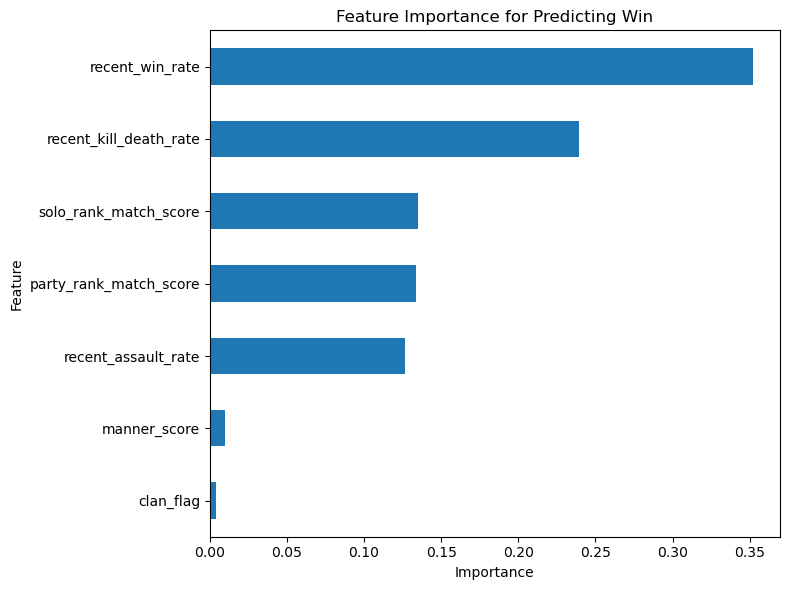

In [52]:
import matplotlib.pyplot as plt

# 중요도 추출 (grid_search 사용 시 best_estimator_ 활용)
feature_importance = pd.Series(grid_search.best_estimator_.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh')
plt.title("Feature Importance for Predicting Win")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [53]:
df_match[df_match['ouid']=='9b2852e25a85deebc5ce4173b1ccc1e6']

,match_id,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,2025-07-29,1.0,12.0,6.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6
1,2.507292e+17,2025-07-29,1.0,17.0,9.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6
2,2.507292e+17,2025-07-29,1.0,15.0,7.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6
3,2.507281e+17,2025-07-28,1.0,5.0,1.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6
4,2.507281e+17,2025-07-28,1.0,8.0,5.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6
...,...,...,...,...,...,...,...
995,2.501262e+17,2025-01-26,3.0,3.0,0.0,0.0,9b2852e25a85deebc5ce4173b1ccc1e6
996,2.501262e+17,2025-01-26,1.0,10.0,9.0,3.0,9b2852e25a85deebc5ce4173b1ccc1e6
997,2.501262e+17,2025-01-26,1.0,0.0,3.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6
998,2.501262e+17,2025-01-26,1.0,12.0,10.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [ ]:
df_match['is_win'] = df_match['match_result'].apply(lambda x: 1 if x == 1 else 0)
df_match['is_draw'] = df_match['match_result'].apply(lambda x: 1 if x == 3 else 0)
df_match['is_loss'] = df_match['match_result'].apply(lambda x: 1 if x == 2 else 0)

user_summary = df_match.groupby('ouid')[['is_win', 'is_draw', 'is_loss']].sum().reset_index()

user_summary['total_matches'] = (
    user_summary['is_win'] + user_summary['is_draw'] + user_summary['is_loss']
)
user_summary['actual_win_rate'] = user_summary['is_win'] / user_summary['total_matches']

In [58]:
user_summary

,ouid,is_win,is_draw,is_loss,total_matches,actual_win_rate
0,003d0b600c59e36feaa73cca3994a408,548,14,224,786,0.697201
1,012e622254f0024d03b6e88db7b62e22,25,0,3,28,0.892857
2,0136f10d0f040ceb86007bbb3ef41231,440,4,7,451,0.975610
3,018eec186511a63ea86738c7799252e0,88,1,11,100,0.880000
4,01e418adbb180c3899de0ae34dd9789f,186,4,16,206,0.902913
...,...,...,...,...,...,...
716,fee4da8dfda5ea8382ed70af8a0daddc,622,9,91,722,0.861496
717,ff0a3be194396e139d9aaf35f2a53c48,229,9,71,309,0.741100
718,ff1fb9a283d02bc12a4059b277cb9cd3,245,2,14,261,0.938697
719,ff553d41736f8cd4ac40adcea1e066ed,305,2,275,582,0.524055


In [62]:
len(df_match[df_match['ouid']=='003d0b600c59e36feaa73cca3994a408'])

786

In [60]:
user_summary[user_summary['ouid']=='003d0b600c59e36feaa73cca3994a408']

,ouid,is_win,is_draw,is_loss,total_matches,actual_win_rate
0,003d0b600c59e36feaa73cca3994a408,548,14,224,786,0.697201


In [63]:
df_match

,match_id,date_match,match_result,kill,death,assist,ouid,is_win,is_draw,is_loss
0,2.507292e+17,2025-07-29,1.0,12.0,6.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6,1,0,0
1,2.507292e+17,2025-07-29,1.0,17.0,9.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6,1,0,0
2,2.507292e+17,2025-07-29,1.0,15.0,7.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6,1,0,0
3,2.507281e+17,2025-07-28,1.0,5.0,1.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6,1,0,0
4,2.507281e+17,2025-07-28,1.0,8.0,5.0,4.0,9b2852e25a85deebc5ce4173b1ccc1e6,1,0,0
...,...,...,...,...,...,...,...,...,...,...
234956,2.501242e+17,2025-01-24,1.0,13.0,5.0,3.0,2201e38168ca744bc2de0b894831b828,1,0,0
234957,2.501242e+17,2025-01-24,1.0,10.0,6.0,3.0,2201e38168ca744bc2de0b894831b828,1,0,0
234958,2.501242e+17,2025-01-24,1.0,2.0,1.0,1.0,2201e38168ca744bc2de0b894831b828,1,0,0
234959,2.501242e+17,2025-01-24,2.0,9.0,12.0,3.0,2201e38168ca744bc2de0b894831b828,0,0,1
